# Detecting Synthetic Images in AWS SageMaker

In this project I will use the CIFAKE dataset to train and deploy a Binary Classifier for detecting synthetically generated images.

First install some dependencies:

In [1]:
!pip install protobuf==3.19

  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


In [2]:
!pip install smdebug

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyinstrument-cext: filename=pyinstrument_cext-0.2.4-cp312-cp312-linux_x86_64.whl size=6440 sha256=1f9dcc130e5e4b97122fcc53eacebc75ec563b50914244b9fd14271a039e0068
  Stored in directory: /home/ec2-user/.cache/pip/wheels/f9/d7/e0/938c359be77dcd8423fe32988bb00b72f5f1410088b07f181b
Successfully built pyinstrument-cext
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.19.0
    Uninstalling protobuf-3.19.0:
      Successfully uninstalled protobuf-3.19.0m━━━━━━━━━━━━━━━━━━━ 2/4 [protobuf]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [smdebug]m3/4 [smdebug]]


In [3]:
!pip install torch

  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparselt_cu12-0.6.2-py3-none-manylinux2014_x86_64.whl.metadata (6.8 kB)
  Using cached nvidia_nccl_cu

In [112]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 99.2 MB/s  0:00:00


## 1. Dataset preparation

Libraries used in this section:

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

We download the dataset from kaggle, unzip it, and upload it to S3 for training.

In [4]:
!curl -L -o cifake-real-and-ai-generated-synthetic-images.zip\
  https://www.kaggle.com/api/v1/datasets/download/birdy654/cifake-real-and-ai-generated-synthetic-images

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  104M  100  104M    0     0   101M      0  0:00:01  0:00:01 --:--:--  128M


In [ ]:
%%capture
!unzip cifake-real-and-ai-generated-synthetic-images -d cifake/

In [ ]:
%%capture
!aws s3 sync cifake s3://detecting-synthetic-images-sagemaker/input_data/cifake/

We can explore a few of the images:

Fake image:

In [28]:
img = Image.open("./cifake/train/FAKE/1000 (10).jpg")

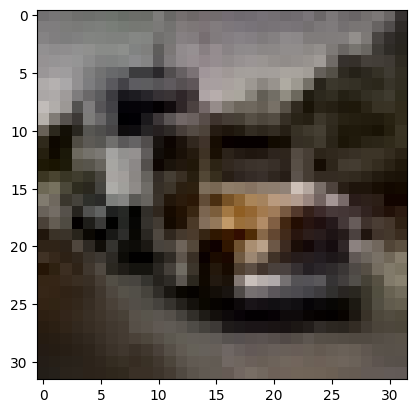

In [29]:
plt.imshow(img)

Real image:

In [30]:
img = Image.open("./cifake/train/REAL/1000 (10).jpg")

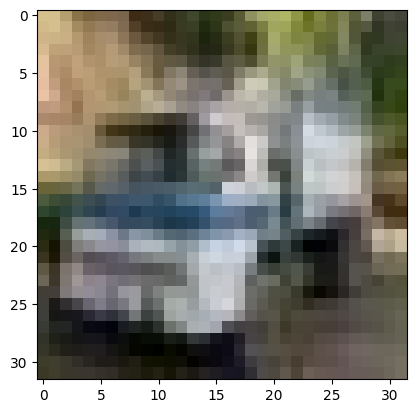

In [31]:
plt.imshow(img)

As we can see, to the naked eye, it's hard to see a difference at 32x32 resolution.

In [32]:
img.size

(32, 32)

## 2. Hyperparameter Tuning

I tune the model's Learning Rate and Batch Size using 5 training jobs. The tuner will look for the lowest Binary Cross Entropy Loss obtained, and return that as the best estimator. The training job is configured to stop early if it detects the training loss to have increased between epochs

Libraries used in this section:

In [18]:
import pandas as pd
from sagemaker.tuner import (
    IntegerParameter,
    CategoricalParameter,
    ContinuousParameter,
    HyperparameterTuner,
)
import sagemaker
from sagemaker.pytorch import PyTorch

In [7]:
hyperparameter_ranges = {
    "learning_rate": ContinuousParameter(0.001, 0.005),
    "batch_size": CategoricalParameter([128, 256, 512, 1024, 2048, 4056])
}

objective_metric_name = "Binary Cross Entropy Loss"
objective_type = "Minimize"
metric_definitions = [{"Name": objective_metric_name, "Regex": "Testing Loss: (-?[0-9\\.]+)"}]

In [8]:
role = sagemaker.get_execution_role()

estimator = PyTorch(
    entry_point="hpo.py",
    role=role,
    source_dir=".",
    py_version='py312',
    framework_version="2.6",
    instance_count=1,
    instance_type="ml.p3.2xlarge"
    #instance_type="ml.t3.2xlarge"
)

tuner = HyperparameterTuner(
    estimator,
    objective_metric_name,
    hyperparameter_ranges,
    metric_definitions,
    max_jobs=5,
    max_parallel_jobs=1,
    objective_type=objective_type,
)

In [9]:
inputs = {
    'train': 's3://detecting-synthetic-images-sagemaker/input_data/cifake/train/',
    'test': 's3://detecting-synthetic-images-sagemaker/input_data/cifake/test/'
}

In [13]:
tuner.fit(inputs=inputs, wait=True)

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating hyperparameter tuning job with name: pytorch-training-260312-1304


...............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................!


In [15]:
best_estimator = tuner.best_estimator()
best_estimator.hyperparameters()


2026-03-12 13:51:15 Starting - Found matching resource for reuse
2026-03-12 13:51:15 Downloading - Downloading the training image
2026-03-12 13:51:15 Training - Training image download completed. Training in progress.
2026-03-12 13:51:15 Uploading - Uploading generated training model
2026-03-12 13:51:15 Completed - Resource released due to keep alive period expiry


{'_tuning_objective_metric': '"Binary Cross Entropy Loss"',
 'batch_size': '"2048"',
 'learning_rate': '0.004035719481029806',
 'sagemaker_container_log_level': '20',
 'sagemaker_estimator_class_name': '"PyTorch"',
 'sagemaker_estimator_module': '"sagemaker.pytorch.estimator"',
 'sagemaker_job_name': '"pytorch-training-2026-03-12-13-04-15-073"',
 'sagemaker_program': '"hpo.py"',
 'sagemaker_region': '"us-east-1"',
 'sagemaker_submit_directory': '"s3://sagemaker-us-east-1-257909240325/pytorch-training-2026-03-12-13-04-15-073/source/sourcedir.tar.gz"'}

If we lose the jupyter session, we can re-attach to the HyperparameterTuner with:

> tuner = HyperparameterTuner.attach("pytorch-training-260312-1304")

## 3.Model Training

In this section, I train the model the full 100 epochs with the best hyperparameters obtained in the past step. I also activate the Debugger and Profiler, which can help find out why a model might not be performing correctly.

For the Debugger rules I chose to check the 'LossNotDecreasing' metric, since this will give us a very good indication of the quality of the training

Libraries used in this section:

In [24]:
import sagemaker
from sagemaker.pytorch import PyTorch
from sagemaker import get_execution_role
from sagemaker.debugger import (
    Rule,
    DebuggerHookConfig,
    rule_configs,
    CollectionConfig
)
from sagemaker.tuner import HyperparameterTuner

I reattach to the hyperparameter tuner

In [25]:
tuner = HyperparameterTuner.attach("pytorch-training-260312-1304")
best_estimator = tuner.best_estimator()


2026-03-12 13:51:15 Starting - Found matching resource for reuse
2026-03-12 13:51:15 Downloading - Downloading the training image
2026-03-12 13:51:15 Training - Training image download completed. Training in progress.
2026-03-12 13:51:15 Uploading - Uploading generated training model
2026-03-12 13:51:15 Completed - Resource released due to keep alive period expiry


In [58]:
best_batchsize = best_estimator.hyperparameters()["batch_size"]
best_lr = best_estimator.hyperparameters()["learning_rate"]
hyperparameters = {"batch_size": best_batchsize, "learning_rate": best_lr}

In [59]:
hyperparameters

{'batch_size': '"2048"', 'learning_rate': '0.004035719481029806'}

In [63]:
from sagemaker.debugger import Rule, ProfilerRule, rule_configs
import smdebug.pytorch as smd

rules = [
    # Detect when loss stops decreasing
    Rule.sagemaker(
        rule_configs.loss_not_decreasing(),
        rule_parameters={
            'collection_names': 'losses',
            'num_steps': '10',  # Check over 10 steps
            'diff_percent': '0.1'  # Alert if change < 0.1%
        },
        collections_to_save=[
            CollectionConfig(
            name='losses',
            parameters={
                'save_interval': '10'  # Save every 10 steps
            }
        ),
        ]
    ),
    # Detect vanishing gradients
    Rule.sagemaker(
        rule_configs.vanishing_gradient(),
        rule_parameters={
            'threshold': '0.0000001'  # Gradient magnitude threshold
        },
        collections_to_save=[
            CollectionConfig(
                name="gradients",
                parameters={
                    "save_interval": "100"
                }
            )
        ]
    ),
    # Detect exploding tensor values
    Rule.sagemaker(
        rule_configs.exploding_tensor(),
        rule_parameters={
            'collection_names': 'weights,gradients',
            'only_nan': 'False'
        },
        collections_to_save=[
            CollectionConfig(
                name="weights",
                parameters={
                    "save_interval": "100"
                }
            )
        ]
    ),
    ProfilerRule.sagemaker(rule_configs.ProfilerReport())
]

In [64]:
role = sagemaker.get_execution_role()

estimator = PyTorch(
    entry_point="train_model.py",
    source_dir=".",
    role=role,
    py_version='py312',
    framework_version="2.6",
    instance_count=1,
    instance_type="ml.p3.2xlarge",
    hyperparameters=hyperparameters,
    ## Debugger parameters
    rules=rules
)

In [65]:
inputs = {
    'train': 's3://detecting-synthetic-images-sagemaker/input_data/cifake/train/',
    'test': 's3://detecting-synthetic-images-sagemaker/input_data/cifake/test/'
}

In [66]:
estimator.fit(inputs=inputs, wait=False)

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: pytorch-training-2026-03

I can check the rules during and after training, to see if any were triggered:

In [80]:
import boto3

# Check rule evaluation status while training is running
client = boto3.client('sagemaker')

job_name = estimator.latest_training_job.name
description = client.describe_training_job(TrainingJobName=job_name)

# Each rule runs as a separate processing job
for rule_eval in description.get('DebugRuleEvaluationStatuses', []):
    print(f"Rule: {rule_eval['RuleConfigurationName']}")
    print(f"  Status: {rule_eval['RuleEvaluationStatus']}")
    if 'StatusDetails' in rule_eval:
        print(f"  Details: {rule_eval['StatusDetails']}")
    print()

Rule: LossNotDecreasing
  Status: NoIssuesFound

Rule: VanishingGradient
  Status: NoIssuesFound

Rule: ExplodingTensor
  Status: NoIssuesFound



In [81]:
from smdebug.trials import create_trial
from smdebug.core.modes import ModeKeys

trial = create_trial(estimator.latest_job_debugger_artifacts_path())

trial.tensor_names()

[2026-03-13 10:47:42.150 ip-172-21-167-180.ec2.internal:7614 INFO s3_trial.py:42] Loading trial debug-output at path s3://sagemaker-us-east-1-257909240325/pytorch-training-2026-03-13-08-07-54-900/debug-output
[2026-03-13 10:47:42.785 ip-172-21-167-180.ec2.internal:7614 WARNING s3handler.py:184] Encountered the exception An error occurred while reading from response stream: ("Connection broken: BrokenPipeError(32, 'Broken pipe')", BrokenPipeError(32, 'Broken pipe')) while reading s3://sagemaker-us-east-1-257909240325/pytorch-training-2026-03-13-08-07-54-900/debug-output/index/000000000/000000000620_worker_0.json . Will retry now


['BCEWithLogitsLoss_output_0',
 'VGG_classifier.0.weight',
 'VGG_classifier.3.weight',
 'VGG_classifier.6.weight',
 'VGG_classifier.7.weight',
 'VGG_features.0.weight',
 'VGG_features.1.weight',
 'VGG_features.10.weight',
 'VGG_features.11.weight',
 'VGG_features.14.weight',
 'VGG_features.15.weight',
 'VGG_features.17.weight',
 'VGG_features.18.weight',
 'VGG_features.20.weight',
 'VGG_features.21.weight',
 'VGG_features.23.weight',
 'VGG_features.24.weight',
 'VGG_features.27.weight',
 'VGG_features.28.weight',
 'VGG_features.3.weight',
 'VGG_features.30.weight',
 'VGG_features.31.weight',
 'VGG_features.33.weight',
 'VGG_features.34.weight',
 'VGG_features.36.weight',
 'VGG_features.37.weight',
 'VGG_features.4.weight',
 'VGG_features.40.weight',
 'VGG_features.41.weight',
 'VGG_features.43.weight',
 'VGG_features.44.weight',
 'VGG_features.46.weight',
 'VGG_features.47.weight',
 'VGG_features.49.weight',
 'VGG_features.50.weight',
 'VGG_features.7.weight',
 'VGG_features.8.weight',

With the debugger I plot the results of the Loss tensor:

In [94]:
def get_data(trial, tname, mode):
    tensor = trial.tensor(tname)
    steps = tensor.steps(mode=mode)
    vals = []
    for s in steps:
        vals.append(tensor.value(s, mode=mode))
    return steps, vals

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import host_subplot

def plot_tensor(trial, tensor_name):

    steps_train, vals_train = get_data(trial, tensor_name, mode=ModeKeys.TRAIN)
    print("loaded TRAIN data")
    fig = plt.figure(figsize=(10, 7))
    host = host_subplot(111)

    host.set_xlabel("Steps (TRAIN)")
    host.set_ylabel(tensor_name)

    (p1,) = host.plot(steps_train, vals_train, label=tensor_name)
    print("completed TRAIN plot")
    plt.hlines(0.5252607125282288, color='red', linestyles='dashed', label='Achieved Loss on the Test dataset', xmin=0, xmax=max(steps_train))

    leg = plt.legend()

    plt.ylabel(tensor_name)

    plt.show()

loaded TRAIN data
completed TRAIN plot


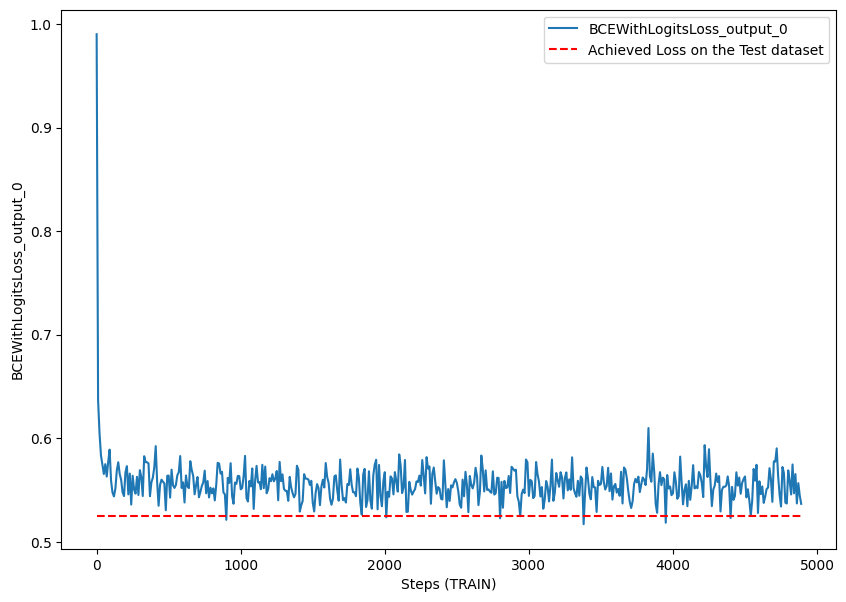

In [95]:
plot_tensor(trial, "BCEWithLogitsLoss_output_0")

In [96]:
rule_output_path = estimator.output_path + estimator.latest_training_job.job_name + "/rule-output"

In [97]:
rule_output_path

's3://sagemaker-us-east-1-257909240325/pytorch-training-2026-03-13-08-07-54-900/rule-output'

In [100]:
! aws s3 cp {rule_output_path} ./ --recursive

download: s3://sagemaker-us-east-1-257909240325/pytorch-training-2026-03-13-08-07-54-900/rule-output/ProfilerReport/profiler-output/profiler-report.ipynb to ProfilerReport/profiler-output/profiler-report.ipynb
download: s3://sagemaker-us-east-1-257909240325/pytorch-training-2026-03-13-08-07-54-900/rule-output/ProfilerReport/profiler-output/profiler-reports/IOBottleneck.json to ProfilerReport/profiler-output/profiler-reports/IOBottleneck.json
download: s3://sagemaker-us-east-1-257909240325/pytorch-training-2026-03-13-08-07-54-900/rule-output/ProfilerReport/profiler-output/profiler-reports/LoadBalancing.json to ProfilerReport/profiler-output/profiler-reports/LoadBalancing.json
download: s3://sagemaker-us-east-1-257909240325/pytorch-training-2026-03-13-08-07-54-900/rule-output/ProfilerReport/profiler-output/profiler-report.html to ProfilerReport/profiler-output/profiler-report.html
download: s3://sagemaker-us-east-1-257909240325/pytorch-training-2026-03-13-08-07-54-900/rule-output/Profile

In [98]:
import os

# get the autogenerated folder name of profiler report
profiler_report_name = [
    rule["RuleConfigurationName"]
    for rule in estimator.latest_training_job.rule_job_summary()
    if "Profiler" in rule["RuleConfigurationName"]
][0]

The report is not shown here since it crashes the Notebook

## 4. Model Deployment
In this step I deploy the model to a Sagemaker endpoint, where it offers inference via API. For testing purposes, I feed it an image through the predictor SDK

In [122]:
import sagemaker
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import numpy as np
import io
import json

In [ ]:
predictor=estimator.deploy(initial_instance_count=1, instance_type="ml.t2.medium")

-------!

Run a prediction, for this we need to convert the image into a numpy object:

In [112]:
path_to_img = "./cifake/test/FAKE/100 (10).jpg"
img = Image.open(path_to_img)

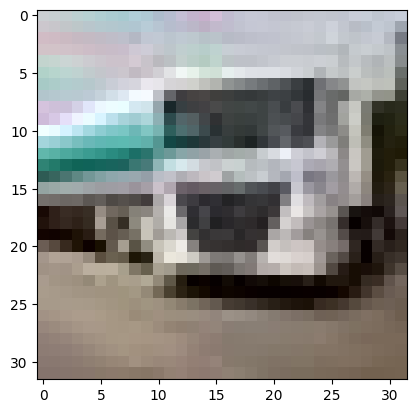

In [113]:
plt.imshow(img)

In [114]:
transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )
img_transformed = transform(img)

In [115]:
image = np.array(img_transformed).astype(np.float32)
image = np.expand_dims(image, axis=0)

In [117]:
ENDPOINT = 'detectingSyntheticImages'

In [133]:
import pickle
import boto3
client = boto3.client("runtime.sagemaker")

image_p = pickle.dumps(image)
print("Image pickled")

# Make a prediction with the boto3 client:
inference = client.invoke_endpoint(
    EndpointName=ENDPOINT, Body=image_p, ContentType="application/x-npy"
)
print(f"Data {inference} received")
inferences = inference["Body"].read().decode().replace("[", "").replace("]", "")
print(f"Raw inference {inferences} received")

import torch
from torch import nn
s = nn.Sigmoid()
prediction = s(torch.Tensor([float(inferences)])).item()

print(f"Prediction {prediction}")

Image pickled
Data {'ResponseMetadata': {'RequestId': 'd39e6de3-d4f9-4e60-88cc-62b9cca55264', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': 'd39e6de3-d4f9-4e60-88cc-62b9cca55264', 'x-amzn-invoked-production-variant': 'AllTraffic', 'date': 'Mon, 16 Mar 2026 15:53:05 GMT', 'content-type': 'application/json', 'content-length': '23', 'connection': 'keep-alive'}, 'RetryAttempts': 0}, 'ContentType': 'application/json', 'InvokedProductionVariant': 'AllTraffic', 'Body': <botocore.response.StreamingBody object at 0x7fe174c79870>} received
Raw inference 0.31696081161499023 received
Prediction 0.5785834193229675


Get the predicted class, taking into account that FAKE is an output close to 0 and REAL is an output close to 1:

In [134]:
if prediction >= 0.5:
    print(f"The network predicted a REAL image with {round((prediction*100), 2)}% confidence")
else:
    print(f"The network predicted a FAKE image with {round(((1-prediction)*100), 2)}% confidence")

The network predicted a REAL image with 57.86% confidence
